In [1]:
from pyCicero import preprocess
from pyCicero import run_cicero
from pyCicero import annotate_peaks
from pyCicero import correlate_peaks

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.io import mmread

In [19]:
counts = mmread("../make_cicero_cds_R_Objs/full_matrix.mtx").T.tocsr()
obs_names = pd.read_csv("../make_cicero_cds_R_Objs/full_meta.csv", header = 0, index_col = 0)
var_names = pd.read_csv("../make_cicero_cds_R_Objs/full_matrix_rownames.csv", header = 0, index_col = 1)
var_names.drop("Unnamed: 0", axis = 1, inplace = True)
# obs_names.drop("Unnamed: 0", axis = 1, inplace = True)

In [20]:
counts.data[counts.data > 0] = 1
shuffle = True
if shuffle:
    rng = np.random.RandomState(0)
    counts = counts[:, rng.permutation(counts.shape[1])]

In [21]:
adata = sc.AnnData(counts, obs = obs_names, var = var_names)

In [27]:
adata

AnnData object with n_obs × n_vars = 37584 × 266716
    obs: 'orig.ident', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_RNA', 'nFeature_RNA', 'segment', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'ATAC.weight', 'cell_type', 'cluster', 'group'

In [22]:
adata = preprocess.preprocess_cicero(adata)

preprocess.py: 2025-04-22 19:23:22 WARNING  Counts layers not found. Coppying X to counts


preprocess.py: 2025-04-22 19:23:23 INFO     Estimaing Size Factors and Normalizing Data
preprocess.py: 2025-04-22 19:23:44 INFO     Finished Size Factors and Normallization storing normalized sparse matrix into 'data'
preprocess.py: 2025-04-22 19:23:44 INFO     Running TF-IDF
preprocess.py: 2025-04-22 19:23:49 INFO     Finsihed TF-IDF
preprocess.py: 2025-04-22 19:23:49 INFO     Running TruncatedSVD
preprocess.py: 2025-04-22 19:26:16 INFO     Finsihed TruncatedSVD
preprocess.py: 2025-04-22 19:26:16 INFO     Running UMAP
preprocess.py: 2025-04-22 19:26:16 INFO     Finsihed UMAP


In [23]:
cicero_adata = preprocess.make_cicero_adata(adata, k = 50)

preprocess.py: 2025-04-22 19:26:16 INFO     Using adata OBSM X_umap to agregate cells
preprocess.py: 2025-04-22 19:26:16 INFO     Calculating overlap
preprocess.py: 2025-04-22 19:26:17 INFO     Generating Pseudobulk cicero observations with seed: 0 and k: 50
preprocess.py: 2025-04-22 19:26:40 INFO     Reached Maximum itterations in pseudobulk observation generation. Consider increasing 'max_itterations'
preprocess.py: 2025-04-22 19:26:40 INFO     Found 4496 good choices
preprocess.py: 2025-04-22 19:26:40 INFO     Finished calculating overlap
preprocess.py: 2025-04-22 19:26:40 INFO     Aggregating Cells
preprocess.py: 2025-04-22 19:27:00 INFO     Finished Aggregating Cells


In [24]:
# Preprocess the index strings, assuming format "chr-start-end" (e.g., "chr-0-1923") 
# Also sorted from lower to higher
temp_df = pd.DataFrame([x.split("-") for x in cicero_adata.var.index])
cicero_adata.var["Chromosome"] = temp_df.iloc[:, 0].values
cicero_adata.var["Start"] = temp_df.iloc[:, 1].astype(int).values
cicero_adata.var["End"] = temp_df.iloc[:, 2].astype(int).values
cicero_adata.var["Mean"] = (cicero_adata.var["Start"] + cicero_adata.var["End"])/2

In [25]:
#Usually sorted, if not sort
chromosomes_ordered = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8',
       'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15',
       'chr16', 'chr17', 'chr18', 'chr19', 'chrX', 'chrY', 'GL456211.1',
       'GL456216.1', 'GL456233.1', 'JH584295.1', 'JH584304.1'] #doesn't actually matter
temp_vars = []
for chromosome in chromosomes_ordered:
    chromosome_var = cicero_adata.var[cicero_adata.var["Chromosome"] == chromosome]
    chromosome_var.sort_values("Start", ascending = False) #lower to higher
    temp_vars.append(chromosome_var)
cicero_adata.var = pd.concat(temp_vars, axis = 0)

In [30]:
cicero_adata.var

,Chromosome,Start,End,Mean
x,,,,
chr1-3119740-3120239,chr1,3119740,3120239,3119989.5
chr1-3121226-3121725,chr1,3121226,3121725,3121475.5
chr1-3155081-3155580,chr1,3155081,3155580,3155330.5
chr1-3203852-3204351,chr1,3203852,3204351,3204101.5
chr1-3210121-3210620,chr1,3210121,3210620,3210370.5
...,...,...,...,...
JH584304.1-67266-67765,JH584304.1,67266,67765,67515.5
JH584304.1-67886-68385,JH584304.1,67886,68385,68135.5
JH584304.1-68747-69246,JH584304.1,68747,69246,68996.5


In [27]:
cicero_adata

AnnData object with n_obs × n_vars = 4496 × 266716
    obs: 'orig.ident', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_RNA', 'nFeature_RNA', 'segment', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'ATAC.weight', 'cell_type', 'cluster', 'group', 'aggregate_obs_names'
    var: 'Chromosome', 'Start', 'End', 'Mean'

In [31]:
"""
probably from inverse_covriance (skggm)
from: Starting distance_parameter_estimation
/home/twoo/miniconda3/envs/rapids_SC/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
"""
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*force_all_finite.*")

In [32]:
cons = run_cicero.run_cicero(cicero_adata)

run_cicero.py: 2025-04-22 19:27:27 INFO     Generating Windows
run_cicero.py: 2025-04-22 19:27:28 INFO     Starting distance_parameter_estimation
run_cicero.py: 2025-04-22 19:35:30 INFO     Starting multiprocessing pool for estimate_distance_parameter_parallel with 96 processes
run_cicero.py: 2025-04-22 19:35:55 INFO     Finished distance_parameter_estimation
run_cicero.py: 2025-04-22 19:35:55 INFO     Starting generate_cicero_models
run_cicero.py: 2025-04-22 19:36:57 INFO     Starting Cicero with 96 processes
run_cicero.py: 2025-04-22 19:37:20 INFO     Finished generate_cicero_models
run_cicero.py: 2025-04-22 19:37:21 INFO     Starting assemble_connections
run_cicero.py: 2025-04-22 19:37:47 INFO     Finished assemble_connections


In [33]:
tss = pd.read_csv("./gencode.vM23.annotation.gff3.gz.tss.bed", sep = "\t", header = None, names = ["Chromosome", "TSS"])
genes_df = pd.read_csv("./gencode.vM23.annotation.gff3.gz.gene.bed", sep = "\t", header = None, names = ["chr", "start", "end", "gene_name"])

cons = annotate_peaks.expand_cons(cons)
cons = annotate_peaks.annotate_distal_proximal(cons, tss)
cons = annotate_peaks.annotate_genes(cons, genes_df)

annotate_peaks.py: 2025-04-22 19:38:59 WARNING  GTF file did not contain all chromosomes or some chromosome names did not match disregarding closest TSS for the following chromosomes: ['GL456211.1' 'GL456216.1' 'GL456233.1' 'JH584295.1' 'JH584304.1']


In [34]:
n_unique_genes = len(set(cons["Peak_2_Gene_Annotation"].values).union(set(cons["Peak_1_Gene_Annotation"].values))) - 2
pct_exons = (pd.notna(cons["Peak_1_Gene_Annotation"]).sum() + pd.notna(cons["Peak_2_Gene_Annotation"]).sum())/(cons.shape[0] * 2) * 100
print(f"Number of Unique Exon Genes: {n_unique_genes}")
print(f"Percent Peaks Exons: {pct_exons:.2f}%")

Number of Unique Exon Genes: 24107
Percent Peaks Exons: 18.00%


In [36]:
import pickle
pickle.dump(cons, open("04_22_25_cons_shuffled.pickle", "wb"))

In [37]:
cons_shuffled = pickle.load(open("04_22_25_cons_shuffled.pickle", "rb"))
cons = pickle.load(open("04_22_25_cons.pickle", "rb"))

In [38]:
import pickle
adata = sc.read_h5ad("../../../spinal_cord_main/03_2025_Objects/Figure 1/03_2025_main_adata.h5ad").raw.to_adata()
mapping_dict = pd.read_csv("../../translated_valid_barcodes_atac.csv").set_index("barcode").iloc[:,0].to_dict()
cicero_adata_shuffled = sc.read_h5ad("./cicero_adata_shuffled.h5ad")
cicero_adata = sc.read_h5ad("./cicero_adata.h5ad")
# cons = pickle.load(open("cons_annotated.pickle", "rb"))
# cons_shuffled = pickle.load(open("cons_shuffled_annotated.pickle", "rb"))

In [39]:
cons = cons[cons["Linkage_Type"].isin(["Distal-to-Proxmial", "Proximal-to-Distal"])]
cons = correlate_peaks.normalize_peak_orientation(cons) #all peaks set to proximal to distal by swapping peak1 and peak2 
cons = cons[~pd.isnull(cons["Peak_1_Gene_Annotation"]) & pd.isnull(cons["Peak_2_Gene_Annotation"])] #lets only analyze genes that are proximal and cCREs
cons = cons.reset_index()
cons = cons.drop(columns="index")

In [40]:
cons_shuffled = cons_shuffled[cons_shuffled["Linkage_Type"].isin(["Distal-to-Proxmial", "Proximal-to-Distal"])]
cons_shuffled = correlate_peaks.normalize_peak_orientation(cons_shuffled) #all peaks set to proximal to distal by swapping peak1 and peak2 
cons_shuffled = cons_shuffled[~pd.isnull(cons_shuffled["Peak_1_Gene_Annotation"]) & pd.isnull(cons_shuffled["Peak_2_Gene_Annotation"])] #lets only analyze genes that are proximal and cCREs
cons_shuffled = cons_shuffled.reset_index()
cons_shuffled = cons_shuffled.drop(columns="index")

In [41]:
aggregate_adata = correlate_peaks.aggregate_adata(adata, cicero_adata, mapping_dict)
cons = correlate_peaks.correlate_peaks(cons, aggregate_adata, cicero_adata)

correlate_peaks.py: 2025-04-22 19:46:25 INFO     Calculating Pearson Correlations


In [42]:
aggregate_adata_shuffled = correlate_peaks.aggregate_adata(adata, cicero_adata_shuffled, mapping_dict)
cons_shuffled = correlate_peaks.correlate_peaks(cons_shuffled, aggregate_adata_shuffled, cicero_adata_shuffled)

correlate_peaks.py: 2025-04-22 19:47:41 INFO     Calculating Pearson Correlations


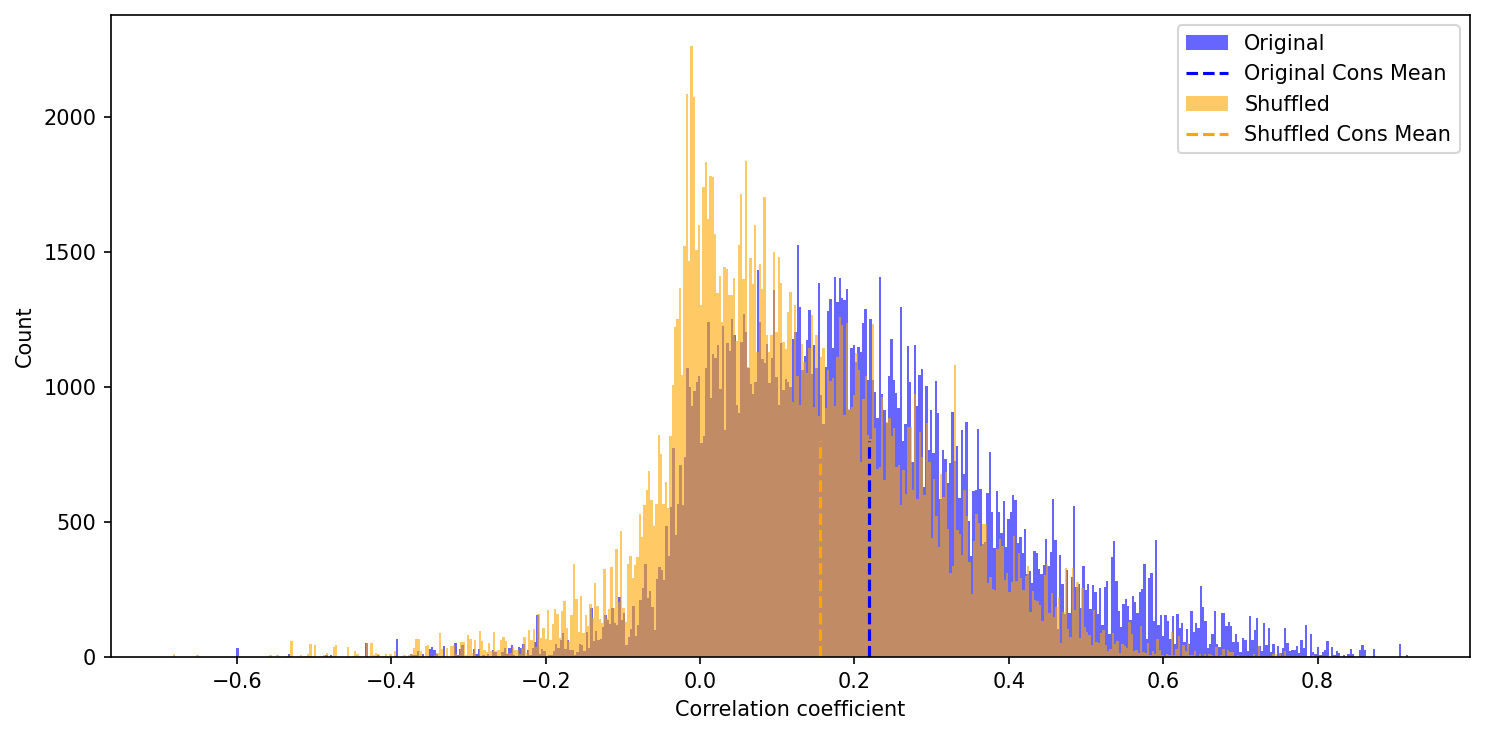

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

ax.hist(cons["Correlation Coefficient"], bins=500, color="blue", alpha=0.6, label="Original")
ax.vlines(np.mean(np.abs(cons["Correlation Coefficient"])), ymin=0, ymax=800, colors="blue", linestyles="dashed", label="Original Cons Mean")

ax.hist(cons_shuffled["Correlation Coefficient"], bins=500, color="orange", alpha=0.6, label="Shuffled")
ax.vlines(np.mean(np.abs(cons_shuffled["Correlation Coefficient"])), ymin=0, ymax=800, colors="orange", linestyles="dashed", label="Shuffled Cons Mean")

ax.set_xlabel("Correlation coefficient")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
aggregate_adata = correlate_peaks.aggregate_adata(adata, cicero_adata, mapping_dict)
cons = correlate_peaks.correlate_peaks(cons, aggregate_adata, cicero_adata, method = "partial") #uses too much memory \_(;_;)_/

In [ ]:
aggregate_adata_shuffled = correlate_peaks.aggregate_adata(adata, cicero_adata_shuffled, mapping_dict)
cons_shuffled = correlate_peaks.correlate_peaks(cons_shuffled, aggregate_adata_shuffled, cicero_adata_shuffled, method = "partial")